# Absorption and Diffusion

This part is meant to combine all our previous results for absorption, diffusion, and convection shown in the previous three notebooks. The goal is to solve for:

\begin{equation}
\left\{\begin{aligned}
    \partial_t\rho_g&= D(\Delta\rho_g)-\mathbf{v}\cdot(\nabla\rho_g) \\
    \partial_t\rho_s&= 0
\end{aligned}\right.
\end{equation}
Where $\rho_g$ is the density at that point and $\rho_s$ is the saturation of the metal. $D$ is the diffusivity, and $\mathbf{v}$ the velocity ($\mathbf v=(v_x, v_y)$).

Under initial condition and boundary conditions are (since there is no coupling effects of saturation of the metal I am pretty sure we do not need boundary conditions there, but I'll look into this and phrase it more rigorous):

\begin{equation}
\left\{ \begin{aligned}
    \rho_g(\mathbf{x}, 0)  &= 0, &\forall \mathbf{x}\in \Omega,\\
    \rho_s(\mathbf{x},0) &= 0, &\forall \mathbf{x}\in \Omega,\\
    \rho_g(\mathbf{x}, t)  &= 1, &\forall \mathbf{x}\in\partial\Omega_1,\forall t\geq 0, \\
    \partial_\mathbf{n}\rho_g(\mathbf{x}, t)  &= 0, &\forall \mathbf{x}\in\partial\Omega_2,\forall t\geq 0. \\
\end{aligned}\right.
\end{equation}

where $\mathbf x = (x, y)$. Since the saturation equation contains no spatial derivatives, $\rho_s$ is governed by a local ordinary differential equation and therefore only requires an initial condition, not a boundary condition. The function for calculating adsorption is simplified into:

$$
\dot m(\rho_g, \rho_s) = k\rho_g(\rho_{sat}-\rho_s)
$$

We will be expanding $\hat\rho_g$, $\hat\rho_s$, and $\hat{\dot m}$ (the values at their respective timesteps) into Lagrange polynomials. In our case now we do not yet discretize into time since the solver will do that for us. Previously we would be working with $\rho_g^n$, as indication of time steps, now $\hat{}$ will indicate the last step before time discretization (so the final semi-discrete formulation):

\begin{equation*}
\begin{aligned}
\hat\rho_g(x, t)&=\sum{\hat \rho_g^{i}(t)\psi^i(x)},\\
\hat\rho_s(x, t)&=\sum{\hat \rho_s^{i}(t)\psi^i(x)},\\
\hat{\dot m}(x, t)&=\sum{\hat {\dot m}^{i}(t)\psi^i(x)}.
\end{aligned}
\end{equation*}

we want to solve for $\hat \rho_g$ and $\hat \rho_s$, so our solution vector $\hat {\mathbf{u}}$ becomes:

$$
\hat{\mathbf{u}} = \begin{pmatrix}\hat\rho_g^{1} \\ \vdots \\ \hat\rho_g^{N} \\ \hat\rho_s^{1} \\ \vdots \\ \hat\rho_s^{N}
\end{pmatrix}
$$

We also define the vector $\hat{\mathbf{\dot{m}}}$ by the coefficients of the absorption:

\begin{equation*}
\hat{\mathbf{\dot{m}}}_h =\begin{pmatrix}
\hat m^{1}\\ \vdots \\ \hat m^{N}
\end{pmatrix},\\
\end{equation*}


Our last semi-discrete step becomes now:

$$
M(\partial_t \hat {\mathbf{u}})  = -(K+C)\hat{\mathbf{u}}+
\begin{pmatrix}-M^{gg}\\M^{ss}\end{pmatrix}\hat{\mathbf{\dot{m}}}_h\\
M(\partial_t \hat {\mathbf{u}})=A\hat{\mathbf{u}}+R(\hat{\mathbf{u}})
$$

where (we initially have both $\rho_g$ and $\rho_s$ be the same Lagrange polynomial degree):

\begin{equation*}
\begin{aligned}
M &= 
    \begin{pmatrix}
        M^{gg} & 0 \\ 
        0      & M^{ss}
    \end{pmatrix}\\
M^{gg}_{ij}=M^{ss}_{ij}&=\int \psi^i\psi^j dx\\
K &= \begin{pmatrix}
        K^{gg} & 0 \\ 
        0      & 0
    \end{pmatrix}\\
K^{gg}&=D\int(\nabla \psi^i)(\nabla\psi^j)dx \\
C &= \begin{pmatrix}
        C^{gg} & 0 \\ 
        0      & 0
    \end{pmatrix}\\
C^{gg}_{ij}&=\mathbf{v}\cdot\int(\nabla\psi^i)\psi^jdx\\
\hat{\dot{m}}^i_h&=k\hat\rho_g^i(\rho_{sat}-\hat\rho^i_s)
\end{aligned}
\end{equation*}

## Import Julia Packages 

In [1]:
using Ferrite
using OrdinaryDiffEq
using LinearSolve
using SparseArrays
using LinearAlgebra
using BenchmarkTools

## FEM definitions/Ferrite calls

In [20]:
name = "abs_conv_diff_ODE";

# Stop time, time step
dt = .01;
T = 10.0;
tau = 0.1;

k = 1.0;         # rate of absorption
rho_sat = 1.0;   # saturation density of metal

vx = 0.5;        # x-velocity for convection
vy = 0.0;        # y-velocity for convection
velocity = Vec((vx, vy));
                 # ↑ total velocity 

D = 0.1;         # Diffusivity for diffusion

In [21]:
# generates 20 gridpoints between 
grid = generate_grid(Quadrilateral, (75, 75), Vec((0.0, 0.0)), Vec((1.0, 1.0)));

# generate the same 
qr = QuadratureRule{RefQuadrilateral}(2);

ip_rho = Lagrange{RefQuadrilateral, 1}();
cellvalues_rho = CellValues(qr, ip_rho);

ip_rhos = Lagrange{RefQuadrilateral, 1}()
cellvalues_rhos = CellValues(qr, ip_rhos);

# degree of freedom handler, 
dh = DofHandler(grid)
add!(dh, :rho, ip_rho)
add!(dh, :rho_s, ip_rhos)
close!(dh);

In [22]:
# for now we have no constraints
ch = ConstraintHandler(dh)

#create left_slit
addfacetset!(
    grid,
    "left_slit",
    x -> abs(x[1]) < 1e-8 && 0.25 <= x[2] <= 0.75
)

dbc_left = Dirichlet(
    :rho,
    getfacetset(grid, "left_slit"),
    (x,t) -> 1 - exp(-t/tau)
)

add!(ch, dbc_left)
close!(ch)
update!(ch, 0.0)

## M, K, C, and A matrices definitions and allocations

In [ ]:
function doassemble_M!(M, cellvalues_rho, cellvalues_rhos, dh)
    assembler = start_assemble(M)

    # number of basis functions per field
    n_basefuncs_rho  = getnbasefunctions(cellvalues_rho)
    n_basefuncs_rhos = getnbasefunctions(cellvalues_rhos)

    # loop over all cells
    for cell in CellIterator(dh)
        # get global DOFs for this cell
        cell_dofs = celldofs(cell)
        ndofs_cell = length(cell_dofs)
        Me = zeros(ndofs_cell, ndofs_cell)

        # rho
        Ferrite.reinit!(cellvalues_rho, cell)
        for q in 1:getnquadpoints(cellvalues_rho)
            dx = getdetJdV(cellvalues_rho, q)
            for i in 1:n_basefuncs_rho
                psi_i = shape_value(cellvalues_rho, q, i)
                for j in 1:n_basefuncs_rho
                    psi_j = shape_value(cellvalues_rho, q, j)
                    # :rho DOFs are first in cell_dofs
                    Me[i, j] += psi_i * psi_j * dx
                end
            end
        end

        # rhos
        Ferrite.reinit!(cellvalues_rhos, cell)
        for q in 1:getnquadpoints(cellvalues_rhos)
            dx = getdetJdV(cellvalues_rhos, q)
            for i in 1:n_basefuncs_rhos
                psi_i = shape_value(cellvalues_rhos, q, i)
                for j in 1:n_basefuncs_rhos
                    psi_j = shape_value(cellvalues_rhos, q, j)
                    # :rho_s DOFs are after :rho in cell_dofs
                    offset = n_basefuncs_rho
                    Me[offset + i, offset + j] += psi_i * psi_j * dx
                end
            end
        end
        assemble!(assembler, cell_dofs, Me)
    end

    return M
end

doassemble_M! (generic function with 1 method)

In [24]:
function doassemble_K!(
    K::SparseMatrixCSC, 
    cellvalues_rho::CellValues, 
    cellvalues_rhos::CellValues, 
    dh::DofHandler
    )

    assembler = start_assemble(K)

    # number of basis functions per field
    n_basefuncs_rho  = getnbasefunctions(cellvalues_rho)
    n_basefuncs_rhos = getnbasefunctions(cellvalues_rhos)

    for cell in CellIterator(dh)

        # get global DOFs for this cell
        cell_dofs = celldofs(cell)
        ndofs_cell = length(cell_dofs)
        Ke = zeros(ndofs_cell, ndofs_cell)

        # rho is the only important bit since rho_s does not diffuse
        Ferrite.reinit!(cellvalues_rho, cell)

        for q_point in 1:getnquadpoints(cellvalues_rho)
            dx = getdetJdV(cellvalues_rho, q_point)

            for i in 1:n_basefuncs_rho
                dpsi_i = shape_gradient(cellvalues_rho, q_point, i)

                for j in 1:n_basefuncs_rho
                    dpsi_j = shape_gradient(cellvalues_rho, q_point, j)
                    # D∫ (∇ψ^i) ⋅ (∇ψ^j)dx
                    Ke[i, j] += D * (dpsi_j ⋅ dpsi_i) * dx
                end
            end
        end

        assemble!(assembler, cell_dofs, Ke)
    end

    return K
end


doassemble_K! (generic function with 1 method)

In [25]:
function doassemble_C!(
    K::SparseMatrixCSC, 
    cellvalues_rho::CellValues, 
    cellvalues_rhos::CellValues, 
    dh::DofHandler
    )

    n_basefuncs_rho = getnbasefunctions(cellvalues_rho)
    Ce = zeros(n_basefuncs_rho, n_basefuncs_rho)

    assembler = start_assemble(C)

    for cell in CellIterator(dh)
        
        # get global DOFs for this cell
        cell_dofs = celldofs(cell)
        ndofs_cell = length(cell_dofs)
        Ce = zeros(ndofs_cell, ndofs_cell)

        # rho is the only important bit since rho_s does not diffuse
        Ferrite.reinit!(cellvalues_rho, cell)
        fill!(Ce, 0)

        for q_point in 1:getnquadpoints(cellvalues_rho)
            dx = getdetJdV(cellvalues_rho, q_point)

            for i in 1:n_basefuncs_rho
                psi_i = shape_value(cellvalues_rho, q_point, i)

                for j in 1:n_basefuncs_rho
                    dpsi_j = shape_gradient(cellvalues_rho, q_point, j)
                    # -v \psi^i(\partial_x\psi^j)dx
                    Ce[i, j] += (velocity ⋅ dpsi_j) *  psi_i * dx
                end
            end
        end

        assemble!(assembler, cell_dofs, Ce)
    end

    return C
end


doassemble_C! (generic function with 1 method)

In [26]:
M = allocate_matrix(dh);
K = allocate_matrix(dh);
C = allocate_matrix(dh);

M = doassemble_M!(M, cellvalues_rho, cellvalues_rhos, dh);
K = doassemble_K!(K, cellvalues_rho, cellvalues_rhos, dh);
C = doassemble_C!(C, cellvalues_rho, cellvalues_rhos, dh);

A = -(K+C)

11552×11552 SparseMatrixCSC{Float64, Int64} with 51076 stored entries:
⎡⢿⣷⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎤
⎢⠀⠙⢿⣷⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠙⢿⣷⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠙⢿⣷⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠙⢿⣷⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⢿⣷⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⢿⣷⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⢿⣷⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⢿⣷⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⢿⣷⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⢿⣷⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⢿⣷⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⢿⣷⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⢿⣷⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⢿⣷⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⢿⣷⣄⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⢿⣷⣄⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⢿⣷⣄⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⢿⣷⣄⠀⎥
⎣⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⢿⣷⎦

## ODE Definitions

In [27]:
ndofs_total = ndofs(dh)
u_n = zeros(ndofs_total)
u_0 = zeros(ndofs_total)

apply!(u_n, ch)
apply!(M, ch);

u_0 .= u_n

jac_sparsity = sparse(A);

In [28]:
# To distinguish degrees of freedom from variables. 
rho_dofs = Int[] 
rhos_dofs = Int[] 

for cell in CellIterator(dh) 
    cdofs = celldofs(cell) 
    append!(rho_dofs, cdofs[dof_range(dh, :rho)]) 
    append!(rhos_dofs, cdofs[dof_range(dh, :rho_s)]) 
end 

rho_dofs = unique(rho_dofs); 
rhos_dofs = unique(rhos_dofs);

mdot = zeros(ndofs_total)

11552-element Vector{Float64}:
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 ⋮
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0

In [29]:
struct RHSparams
    A::SparseMatrixCSC{Float64, Int}
    M::SparseMatrixCSC{Float64, Int}
    ch::ConstraintHandler
    dh::DofHandler
    cellvalues_rho::CellValues
    cellvalues_rhos::CellValues
    rho_dofs::Vector{Int}
    rhos_dofs::Vector{Int}    
    mdot::Vector{Float64}
    u::Vector{Float64}
    k::Float64
    rho_sat::Float64
end

p = RHSparams(
    A, 
    M,
    ch, 
    dh, 
    cellvalues_rho, 
    cellvalues_rhos, 
    rho_dofs,
    rhos_dofs,
    mdot,
    copy(u_n),
    k,
    rho_sat
);

In [30]:
function f!(
    du,
    u_c,
    p :: RHSparams,
    t
)
    (; A, M, ch, rho_dofs, rhos_dofs, mdot, u, k, rho_sat) = p;
    
    # we cannot alter u_c, so we allocate a new u 
    # if I understand the tutorial correctly we can increase computation by pre-allocating this variable
    # which we have done by taking it from p?
    u .= u_c;

    # update time-dependent constraint handler 
    # currently ch is dirichlet without a time aspect, so it does nothing
    # I feel like we have this twice (also in the limiter), so maybe one can go?
    update!(ch, t);

    
    # below will be the non-linear contributions
    # important: because of our assumptions above, we iterate over degrees of freedom/nodes, not cells
    # the cell relavance will be added after M*mdot
    
    fill!(mdot, 0);
    @inbounds for i in eachindex(rho_dofs)
        i_rho  = rho_dofs[i]
        i_rhos = rhos_dofs[i]

        md = k * u[i_rho] * (rho_sat - u[i_rhos])

        mdot[i_rhos] += md
        mdot[i_rho]  -= md
    end
    
    # using mul is an inbuilt function that will work better than normal .* -arithmetics
    # also better allocation wise?
    mul!(du, A, u)                  # du .= A * u
    mul!(du, M, mdot, 1.0, 1.0)     # du -> 1.0 * du + 1.0 * M * mdot blijkbaar ? 

    return
end

f! (generic function with 1 method)

In [31]:
# for benchmarking/ testing functions

# size
# ndofs_total = length(u_0)

# test vectors
u_test  = copy(u_0)
du_test = similar(u_0)

# Jacobian matrix (same sparsity as A)
J_test = copy(jac_sparsity)

# time
t_test = 0.5

0.5

In [32]:
@btime f!($du_test, $u_test, $p, 0.5)

  231.600 μs (309 allocations: 5.20 KiB)


In [33]:
rhs = ODEFunction(
    f!, 
    mass_matrix = M; 
    # jac = Jf!, 
    jac_prototype = jac_sparsity
)
problem = ODEProblem(rhs, u_0, (0.0, T), p);

In [34]:
# Wordt na elke tijdstap uitgevoerd om de bc up te daten en drift te corrigeren
function ferrite_limiter!(u, integrator, p, t)
    update!(p.ch, t)
    apply!(u, p.ch)
    return 
end;

In [35]:
struct FreeDofErrorNorm
    ch::ConstraintHandler
end
(fe_norm::FreeDofErrorNorm)(u::Union{AbstractFloat, Complex}, t) = DiffEqBase.ODE_DEFAULT_NORM(u, t)
(fe_norm::FreeDofErrorNorm)(u::AbstractArray, t) = DiffEqBase.ODE_DEFAULT_NORM(u[fe_norm.ch.free_dofs], t)

timestepper = Rodas5P(
    autodiff = false,
    step_limiter! = ferrite_limiter!,
    linsolve = KrylovJL_GMRES()
);

sol = solve(
    problem, 
    timestepper, 
    abstol = 1.0e-2, 
    reltol = 1.0e-3
)

retcode: Success
Interpolation: specialized 4th (Rodas6P = 5th) order "free" stiffness-aware interpolation
t: 341-element Vector{Float64}:
  0.0
  1.0e-6
  0.010000999999999998
  0.033585207869713814
  0.048705411431435
  0.0638256149931562
  0.0789458185548774
  0.09406602211659859
  0.10918622567831979
  0.12430642924004098
  0.13942663280176218
  0.15454683636348338
  0.16966703992520457
  ⋮
  8.262147733272647
  8.385829010856632
  8.514954057541129
  8.649935334050465
  8.791224141603672
  8.939341405062484
  9.094831880302417
  9.258312424332109
  9.430456656259953
  9.612034392470065
  9.803897823870326
 10.0
u: 341-element Vector{Vector{Float64}}:
 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
 [2.1639343601380453e-12, 2.0681023845521757e-12, 2.030318965802109e-12, 2.3403230288961435e-12, 2.3618608503393813e-15, 3.526

In [36]:
sol.destats

SciMLBase.DEStats
Number of function 1 evaluations:                  342958
Number of function 2 evaluations:                  0
Number of W matrix evaluations:                    340
Number of linear solves:                           2720
Number of Jacobians created:                       0
Number of nonlinear solver iterations:             0
Number of nonlinear solver convergence failures:   0
Number of fixed-point solver iterations:           0
Number of fixed-point solver convergence failures: 0
Number of rootfind condition calls:                0
Number of accepted steps:                          340
Number of rejected steps:                          0

I have two methods. One uses this timestepper:

Rodas5P(
    autodiff = false,
    step_limiter! = ferrite_limiter!,
    linsolve = KrylovJL_GMRES()
);

This timestepper than the timestepper without the linsolve, but does not use Jf! (also not in the old parts where Jf! is just a copy of A). 

## plotting/testing

In [37]:
using Plots

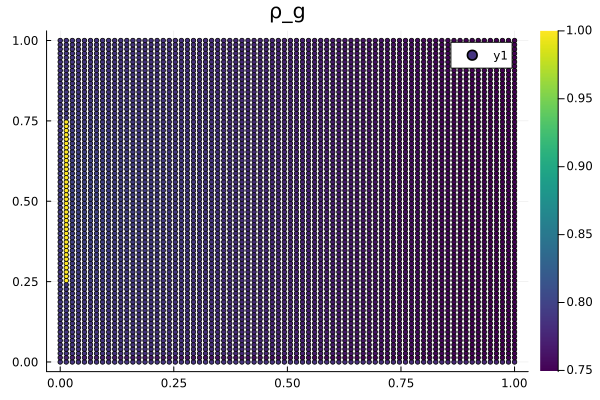

In [39]:
u = sol.u[end]

rho = u[rho_dofs]

coords = [get_node_coordinate(node) for node in grid.nodes]
x = [c[1] for c in coords]
y = [c[2] for c in coords]

scatter(x, y,
    marker_z = rho,
    color = :viridis,
    ms = 2.5,
    colorbar = true,
    title = "ρ_g")

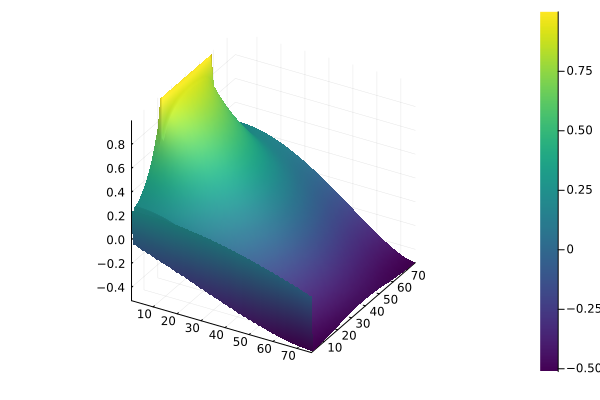

In [60]:
nx, ny = 76, 76  # nodes = elements + 1

rho_grid = reshape(rho, nx, ny)

# heatmap(rho_grid', color = :viridis)
surface(rho_grid', color = :viridis)

## Saving as pvd and vtk

In [40]:
using WriteVTK

In [41]:
pvd = paraview_collection(joinpath(name, name))

times = 0:0.01:sol.t[end]

for (step, t) in enumerate(times)
    u = sol(t)   # <-- interpolation happens here

    VTKGridFile(joinpath(name, "$(name)-$step"), dh) do vtk
        write_solution(vtk, dh, u)
        pvd[t] = vtk
    end
end

vtk_save(pvd)

1002-element Vector{String}:
 "abs_conv_diff_ODE\\abs_conv_diff_ODE.pvd"
 "abs_conv_diff_ODE\\abs_conv_diff_ODE-1.vtu"
 "abs_conv_diff_ODE\\abs_conv_diff_ODE-2.vtu"
 "abs_conv_diff_ODE\\abs_conv_diff_ODE-3.vtu"
 "abs_conv_diff_ODE\\abs_conv_diff_ODE-4.vtu"
 "abs_conv_diff_ODE\\abs_conv_diff_ODE-5.vtu"
 "abs_conv_diff_ODE\\abs_conv_diff_ODE-6.vtu"
 "abs_conv_diff_ODE\\abs_conv_diff_ODE-7.vtu"
 "abs_conv_diff_ODE\\abs_conv_diff_ODE-8.vtu"
 "abs_conv_diff_ODE\\abs_conv_diff_ODE-9.vtu"
 "abs_conv_diff_ODE\\abs_conv_diff_ODE-10.vtu"
 "abs_conv_diff_ODE\\abs_conv_diff_ODE-11.vtu"
 "abs_conv_diff_ODE\\abs_conv_diff_ODE-12.vtu"
 ⋮
 "abs_conv_diff_ODE\\abs_conv_diff_ODE-990.vtu"
 "abs_conv_diff_ODE\\abs_conv_diff_ODE-991.vtu"
 "abs_conv_diff_ODE\\abs_conv_diff_ODE-992.vtu"
 "abs_conv_diff_ODE\\abs_conv_diff_ODE-993.vtu"
 "abs_conv_diff_ODE\\abs_conv_diff_ODE-994.vtu"
 "abs_conv_diff_ODE\\abs_conv_diff_ODE-995.vtu"
 "abs_conv_diff_ODE\\abs_conv_diff_ODE-996.vtu"
 "abs_conv_diff_ODE\\abs_conv_dif

# Benchmarking

In [37]:
@btime f!($du_test, $u_test, $p, $t_test)

  415.700 μs (14 allocations: 624 bytes)


In [57]:
@benchmark f!($du_test, $u_test, $p, $t_test)

BenchmarkTools.Trial: 6649 samples with 1 evaluation per sample.
 Range (min … max):  475.200 μs …   4.352 ms  ┊ GC (min … max): 0.00% … 0.00%
 Time  (median):     670.200 μs               ┊ GC (median):    0.00%
 Time  (mean ± σ):   741.528 μs ± 288.959 μs  ┊ GC (mean ± σ):  0.00% ± 0.00%

  ▁▁▂▂▃▆█▇▆▄▁                                                    
  ███████████▇▆▅▅▄▅▄▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁ ▃
  475 μs           Histogram: frequency by time         1.99 ms <

 Memory estimate: 592 bytes, allocs estimate: 13.

In [33]:
@benchmark Jf!($J_test, $u_test, $p, $t_test)

BenchmarkTools.Trial: 6590 samples with 1 evaluation per sample.
 Range (min … max):  630.700 μs …  12.028 ms  ┊ GC (min … max): 0.00% … 0.00%
 Time  (median):     670.150 μs               ┊ GC (median):    0.00%
 Time  (mean ± σ):   753.442 μs ± 235.821 μs  ┊ GC (mean ± σ):  0.00% ± 0.00%

  ▇█▆▅▄▄▃▃▃▃▃▃▃▃▃▂▂▂▁▁▁▁▁                                       ▂
  █████████████████████████████▇▇▆▇▇▇▇▆▇▆▆▇▆▅▅▆▆▅▄▅▅▃▅▅▄▅▃▄▄▃▄▆ █
  631 μs        Histogram: log(frequency) by time       1.55 ms <

 Memory estimate: 752 bytes, allocs estimate: 17.

In [ ]:
@benchmark ferrite_limiter!($u_test, nothing, $p, $t_test)